# Capstone 2: Business Analysis with Python
## EmporiUm Sales Territory Analysis — Northeast Region

**Analyst:** Betelehem Teklemariam  
**Territories:** Maryland (Shruti Reddy) & Massachusetts (Bo Heap)  
**Region:** Northeast | **Region Director:** Michael Jarvis  

This notebook analyzes in-store sales data for two assigned sales territories 
and provides data-driven insights and marketing recommendations for the next quarter.





























































































































In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.chdir(r'C:\Users\betty\Documents\DATA_Labs\capstone-2-')
print(os.getcwd())

C:\Users\betty\Documents\DATA_Labs\capstone-2-


## Loading the Data


 b

In [2]:
# Load transaction data
store_sales = pd.read_csv('StoreSales.csv')
store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


In [7]:
# Preview first 5 rows of StoreSales
store_sales.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [3]:
# Load store location and territory information
store_detail = pd.read_csv('StoreDetail.csv')
store_detail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [8]:
# Preview first 5 rows of StoreDetail
store_detail.head()

,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [4]:
# Load product details
products = pd.read_csv('Products.csv')
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


In [9]:
# Preview first 5 rows of Products
products.head()

,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [5]:
# Load product categories and subcategories
product_categories = pd.read_csv('ProductCategories.csv')
product_categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


In [10]:
# Preview first 5 rows of ProductCategories
product_categories.head()

,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [6]:
# Load rewards member information
customer_list = pd.read_csv('customer_list.csv', sep='|')
customer_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


In [11]:
# Preview first 5 rows of customer_list
customer_list.head()

,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


## Core Marketing Analysis

### Question 1: Territory Managers, Store IDs and Cities
Who are the territory managers for the assigned sales territories? 
What are the store IDs and cities for the stores in each territory?

In [12]:
# Filter stores for Maryland and Massachusetts territories
md_stores = store_detail[store_detail['State'] == 'Maryland']
ma_stores = store_detail[store_detail['State'] == 'Massachusetts']

# Maryland territory
print("=== Territory 1: Maryland ===")
print(f"Territory Manager: {md_stores['Territory Manager'].unique()[0]}")
print(md_stores[['Store ID', 'Store Location', 'State']].to_string(index=False))

print()

# Massachusetts territory
print("=== Territory 2: Massachusetts ===")
print(f"Territory Manager: {ma_stores['Territory Manager'].unique()[0]}")
print(ma_stores[['Store ID', 'Store Location', 'State']].to_string(index=False))

=== Territory 1: Maryland ===
Territory Manager: Shruti Reddy
 Store ID      Store Location    State
      731           Annapolis Maryland
      732          Back River Maryland
      733           Baltimore Maryland
      734          Germantown Maryland
      735              Howard Maryland
      736       North Harford Maryland
      737           Parkville Maryland
      738 Queen Anne's County Maryland
      739             Ridgely Maryland

=== Territory 2: Massachusetts ===
Territory Manager: Bo Heap
 Store ID Store Location         State
      730         Boston Massachusetts
      801      Attleboro Massachusetts
      802       Falmouth Massachusetts
      803     Framingham Massachusetts
      804      Haverhill Massachusetts
      805        Hingham Massachusetts
      806        Holyoke Massachusetts
      807     Leominster Massachusetts
      808         Lowell Massachusetts
      809           Lynn Massachusetts
      810      Nantucket Massachusetts
      811    New 

**Findings:**
- Territory 1 (Maryland) is managed by **Shruti Reddy** and has **9 stores**
- Territory 2 (Massachusetts) is managed by **Bo Heap** and has **18 stores**
- Both territories are in the **Northeast** region under Region Director **Michael Jarvis**

### Question 2: Monthly Total Revenue
What is the monthly total revenue for in-store sales in each of the 
two sales territories over the full period covered by the data?

In [13]:
# Convert Transaction Date to datetime
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])

# Add Month and Year column
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M')

# Get store IDs for each territory
md_store_ids = md_stores['Store ID'].tolist()
ma_store_ids = ma_stores['Store ID'].tolist()

# Filter sales for each territory
md_sales = store_sales[store_sales['Store ID'].isin(md_store_ids)]
ma_sales = store_sales[store_sales['Store ID'].isin(ma_store_ids)]

# Monthly revenue for each territory
md_monthly = md_sales.groupby('Month')['Sale Amount'].sum().reset_index()
md_monthly.columns = ['Month', 'Maryland Revenue']

ma_monthly = ma_sales.groupby('Month')['Sale Amount'].sum().reset_index()
ma_monthly.columns = ['Month', 'Massachusetts Revenue']

print("=== Maryland Monthly Revenue ===")
print(md_monthly.to_string(index=False))

print("\n=== Massachusetts Monthly Revenue ===")
print(ma_monthly.to_string(index=False))

=== Maryland Monthly Revenue ===
  Month  Maryland Revenue
2022-01         190064.90
2022-02         197529.18
2022-03         210228.48
2022-04         179004.18
2022-05         212028.70
2022-06         198318.98
2022-07         231208.13
2022-08         203503.40
2022-09         158952.74
2022-10         200423.07
2022-11         202365.13
2022-12         226340.81
2023-01         247207.80
2023-02         215146.55
2023-03         212397.10
2023-04         253354.48
2023-05         236271.38
2023-06         243603.42
2023-07         218664.85
2023-08         233256.77
2023-09         227638.37
2023-10         248095.23
2023-11         242019.94
2023-12         236037.31
2024-01         234650.29
2024-02         200891.75
2024-03         263664.98
2024-04         225960.88
2024-05         248901.48
2024-06         213366.79
2024-07         233256.77
2024-08         234863.77
2024-09         240869.83
2024-10         247456.61
2024-11         230600.64
2024-12         247207.80
2025-

**Findings:**
- Data covers **January 2022 through December 2025** (4 years)
- **Maryland** consistently generates higher monthly revenue than Massachusetts
- Both territories show a clear **upward trend** over time
- Maryland revenue grew from ~$190K/month in 2022 to ~$330K/month in 2025
- Massachusetts revenue grew from ~$69K/month in 2022 to ~$186K/month in 2025
- Both territories show strong growth suggesting healthy sales performance

### Question 3: Store Sales Performance Ranking
How would you rank the sales performance of each store in each 
sales territory? Which are the top-performing stores?

In [14]:
# Calculate total revenue per store for each territory
md_store_revenue = md_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()
md_store_revenue.columns = ['Store ID', 'Total Revenue']
md_store_revenue = md_store_revenue.merge(store_detail[['Store ID', 'Store Location']], on='Store ID')
md_store_revenue = md_store_revenue.sort_values('Total Revenue', ascending=False)
md_store_revenue['Rank'] = range(1, len(md_store_revenue) + 1)

ma_store_revenue = ma_sales.groupby('Store ID')['Sale Amount'].sum().reset_index()
ma_store_revenue.columns = ['Store ID', 'Total Revenue']
ma_store_revenue = ma_store_revenue.merge(store_detail[['Store ID', 'Store Location']], on='Store ID')
ma_store_revenue = ma_store_revenue.sort_values('Total Revenue', ascending=False)
ma_store_revenue['Rank'] = range(1, len(ma_store_revenue) + 1)

print("=== Maryland Store Rankings ===")
print(md_store_revenue[['Rank', 'Store ID', 'Store Location', 'Total Revenue']].to_string(index=False))

print("\n=== Massachusetts Store Rankings ===")
print(ma_store_revenue[['Rank', 'Store ID', 'Store Location', 'Total Revenue']].to_string(index=False))

=== Maryland Store Rankings ===
 Rank  Store ID      Store Location  Total Revenue
    1       736       North Harford     8708119.00
    2       734          Germantown      584675.92
    3       737           Parkville      320441.24
    4       735              Howard      319394.58
    5       739             Ridgely      318511.04
    6       733           Baltimore      310099.90
    7       732          Back River      303433.61
    8       738 Queen Anne's County      298074.49
    9       731           Annapolis      288865.31

=== Massachusetts Store Rankings ===
 Rank  Store ID Store Location  Total Revenue
    1       817      Worcester      602183.44
    2       807     Leominster      338009.10
    3       810      Nantucket      335547.81
    4       814   Provincetown      328860.51
    5       812    Northampton      322039.24
    6       806        Holyoke      320516.53
    7       816     Somerville      312873.59
    8       804      Haverhill      305762.60
    9 

**Findings:**
- **Maryland top performer:** North Harford (Store 736) with $8.7M in total revenue — 
significantly higher than all other Maryland stores
- **Maryland lowest performer:** Annapolis (Store 731) with $288K in total revenue
- **Massachusetts top performer:** Worcester (Store 817) with $602K in total revenue
- **Massachusetts lowest performer:** Lowell (Store 808) with $266K in total revenue
- North Harford in Maryland stands out as an exceptional performer — 
its revenue is nearly 15x higher than the second ranked Maryland store
- This suggests North Harford may have a unique advantage worth investigating

### Question 4: Top Customers
Comparing the customer ID from the customer list data with the 
rewards ID from the sales data, who were the top customers in 
each sales territory?

In [15]:
# Merge sales with customer list on RewardsID and cust_id
md_customers = md_sales.merge(customer_list, left_on='RewardsID', right_on='cust_id', how='inner')
ma_customers = ma_sales.merge(customer_list, left_on='RewardsID', right_on='cust_id', how='inner')

# Calculate total spend per customer
md_top_customers = md_customers.groupby(['cust_id', 'name'])['Sale Amount'].sum().reset_index()
md_top_customers.columns = ['Customer ID', 'Name', 'Total Spend']
md_top_customers = md_top_customers.sort_values('Total Spend', ascending=False).head(10)
md_top_customers['Rank'] = range(1, len(md_top_customers) + 1)

ma_top_customers = ma_customers.groupby(['cust_id', 'name'])['Sale Amount'].sum().reset_index()
ma_top_customers.columns = ['Customer ID', 'Name', 'Total Spend']
ma_top_customers = ma_top_customers.sort_values('Total Spend', ascending=False).head(10)
ma_top_customers['Rank'] = range(1, len(ma_top_customers) + 1)

print("=== Top 10 Customers in Maryland ===")
print(md_top_customers[['Rank', 'Customer ID', 'Name', 'Total Spend']].to_string(index=False))

print("\n=== Top 10 Customers in Massachusetts ===")
print(ma_top_customers[['Rank', 'Customer ID', 'Name', 'Total Spend']].to_string(index=False))

=== Top 10 Customers in Maryland ===
 Rank  Customer ID            Name  Total Spend
    1          180      Cole Brown      7602.28
    2          355   Donna Hayward      7081.17
    3          467  Avon Barksdale      6172.68
    4           99      Trent Lane      6076.89
    5           75       Magnitude      5916.81
    6          349           Fezco      5795.71
    7          400   K. McClanahan      5674.84
    8          419 Count von Count      5650.21
    9          283   Joe Keene Jr.      5153.18
   10          137        Nikki N.      5139.67

=== Top 10 Customers in Massachusetts ===
 Rank  Customer ID            Name  Total Spend
    1          292 Beverly Crusher      4758.92
    2          384    Tracy Jordan      4197.55
    3           47      Stanley H.      3979.73
    4            3   Monica Geller      3966.91
    5          188    Mellie Grant      3948.41
    6          300   Julian Bashir      3883.60
    7           17         Mike E.      3788.67
    8   

**Findings:**
- **Maryland top customer:** Cole Brown (ID 180) with $7,602 in total spend
- **Massachusetts top customer:** Beverly Crusher (ID 292) with $4,759 in total spend
- Maryland rewards customers spend significantly more than Massachusetts rewards customers
- Maryland top 10 customers average ~$6,026 per customer
- Massachusetts top 10 customers average ~$3,934 per customer
- This suggests Maryland rewards members are more engaged and higher value customers
- Opportunity: Growing the rewards program in Massachusetts could increase customer spend

### Question 5: Transactions and Revenue by Product Category
What is the number of transactions per month by product category 
in each assigned territory? What is total sales revenue per month 
by category? What might this tell you about the most popular 
products, and where could there be opportunity for growth?

In [16]:
# Merge sales with products and categories
md_products = md_sales.merge(products, on='Prod Num', how='left')
md_products = md_products.merge(product_categories, on=['CategoryID', 'SubcategoryID'], how='left')

ma_products = ma_sales.merge(products, on='Prod Num', how='left')
ma_products = ma_products.merge(product_categories, on=['CategoryID', 'SubcategoryID'], how='left')

# Transactions per category
md_category = md_products.groupby('Category').agg(
    Transactions=('Sale Amount', 'count'),
    Total_Revenue=('Sale Amount', 'sum')
).reset_index().sort_values('Total_Revenue', ascending=False)

ma_category = ma_products.groupby('Category').agg(
    Transactions=('Sale Amount', 'count'),
    Total_Revenue=('Sale Amount', 'sum')
).reset_index().sort_values('Total_Revenue', ascending=False)

print("=== Maryland: Revenue and Transactions by Category ===")
print(md_category.to_string(index=False))

print("\n=== Massachusetts: Revenue and Transactions by Category ===")
print(ma_category.to_string(index=False))

=== Maryland: Revenue and Transactions by Category ===
                Category  Transactions  Total_Revenue
Technology & Accessories         16836     7826937.84
               Textbooks         11639     2021177.87
 Apparel and Merchandise         15547      500587.47
         Books (General)         15335      494845.76
            Art Supplies         15674      493114.72
 Stationery and Supplies         16655      174069.48

=== Massachusetts: Revenue and Transactions by Category ===
                Category  Transactions  Total_Revenue
Technology & Accessories          8724     4059863.21
               Textbooks          5789      998901.78
 Apparel and Merchandise          8314      266531.69
            Art Supplies          7865      246064.01
         Books (General)          3409       99532.89
 Stationery and Supplies          9019       91211.24


**Findings:**
- **Technology & Accessories** is the top revenue category in both territories
  - Maryland: $7.8M | Massachusetts: $4.1M
- **Textbooks** is the second highest revenue category in both territories
  - Maryland: $2M | Massachusetts: $998K
- **Stationery and Supplies** has the most transactions in Massachusetts (9,019) 
  but generates the lowest revenue ($91K) — low price point items
- **Books (General)** has very low transactions in Massachusetts (3,409) 
  compared to Maryland (15,335) — big opportunity for growth!
- **Art Supplies** and **Apparel** perform consistently across both territories
- **Opportunity:** Books (General) is severely underperforming in Massachusetts 
  compared to Maryland — targeted marketing could drive significant growth

In [23]:
# Monthly transactions and revenue by category for Maryland
md_monthly_cat = md_products.groupby(['Month', 'Category']).agg(
    Transactions=('Sale Amount', 'count'),
    Total_Revenue=('Sale Amount', 'sum')
).reset_index()

# Monthly transactions and revenue by category for Massachusetts
ma_monthly_cat = ma_products.groupby(['Month', 'Category']).agg(
    Transactions=('Sale Amount', 'count'),
    Total_Revenue=('Sale Amount', 'sum')
).reset_index()

print("=== Maryland: Monthly Transactions by Category (last 12 months) ===")
print(md_monthly_cat[md_monthly_cat['Month'].astype(str) > '2025'].to_string(index=False))

print("\n=== Massachusetts: Monthly Transactions by Category (last 12 months) ===")
print(ma_monthly_cat[ma_monthly_cat['Month'].astype(str) > '2025'].to_string(index=False))

=== Maryland: Monthly Transactions by Category (last 12 months) ===
  Month                 Category  Transactions  Total_Revenue
2025-01  Apparel and Merchandise           475       16029.38
2025-01             Art Supplies           486       16230.33
2025-01          Books (General)           460       15453.87
2025-01  Stationery and Supplies           566        5816.28
2025-01 Technology & Accessories           416      208204.63
2025-01                Textbooks           106       18113.67
2025-02  Apparel and Merchandise           430       14941.01
2025-02             Art Supplies           419       12100.11
2025-02          Books (General)           410       13775.61
2025-02  Stationery and Supplies           443        4495.11
2025-02 Technology & Accessories           380      199426.07
2025-02                Textbooks           113       18546.66
2025-03  Apparel and Merchandise           424       14028.93
2025-03             Art Supplies           456       16665.38
20

**Monthly Category Findings:**
- **Technology & Accessories** consistently generates the highest revenue 
  every single month in both territories
- **Textbooks** shows seasonal spikes — higher in January, May and September 
  which aligns with back to school periods
- **Books (General)** has very low transactions in Massachusetts every month 
  (30-52) compared to Maryland (235-301) — consistent growth opportunity
- **Stationery and Supplies** has decent transactions but very low revenue 
  in both territories — these are low price point items
- **Apparel and Art Supplies** perform consistently throughout the year 
  with no major seasonal spikes

### 

87
\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\















































































































































































































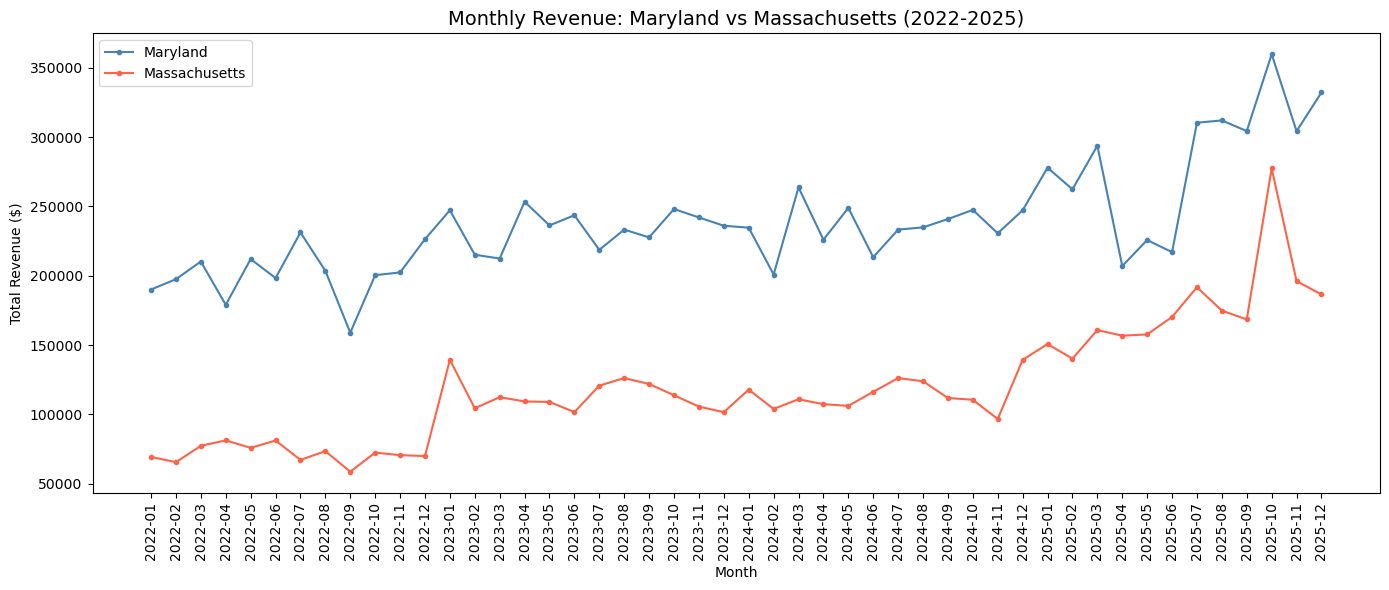

In [17]:
# Chart 1: Monthly Revenue for Maryland vs Massachusetts
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(md_monthly['Month'].astype(str), md_monthly['Maryland Revenue'], 
        color='steelblue', marker='o', markersize=3, label='Maryland')
ax.plot(ma_monthly['Month'].astype(str), ma_monthly['Massachusetts Revenue'], 
        color='tomato', marker='o', markersize=3, label='Massachusetts')

ax.set_title('Monthly Revenue: Maryland vs Massachusetts (2022-2025)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue ($)')
ax.legend()
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

**Chart 1 Insight:**
This line chart shows monthly revenue trends for both territories from 
2022 to 2025. Maryland consistently outperforms Massachusetts in revenue 
but both territories show a clear upward growth trend over the four year 
period. The gap between the two territories appears to be widening in 
2025 suggesting Maryland is growing faster than Massachusetts.

### Chart 2: Total Revenue by Product Category

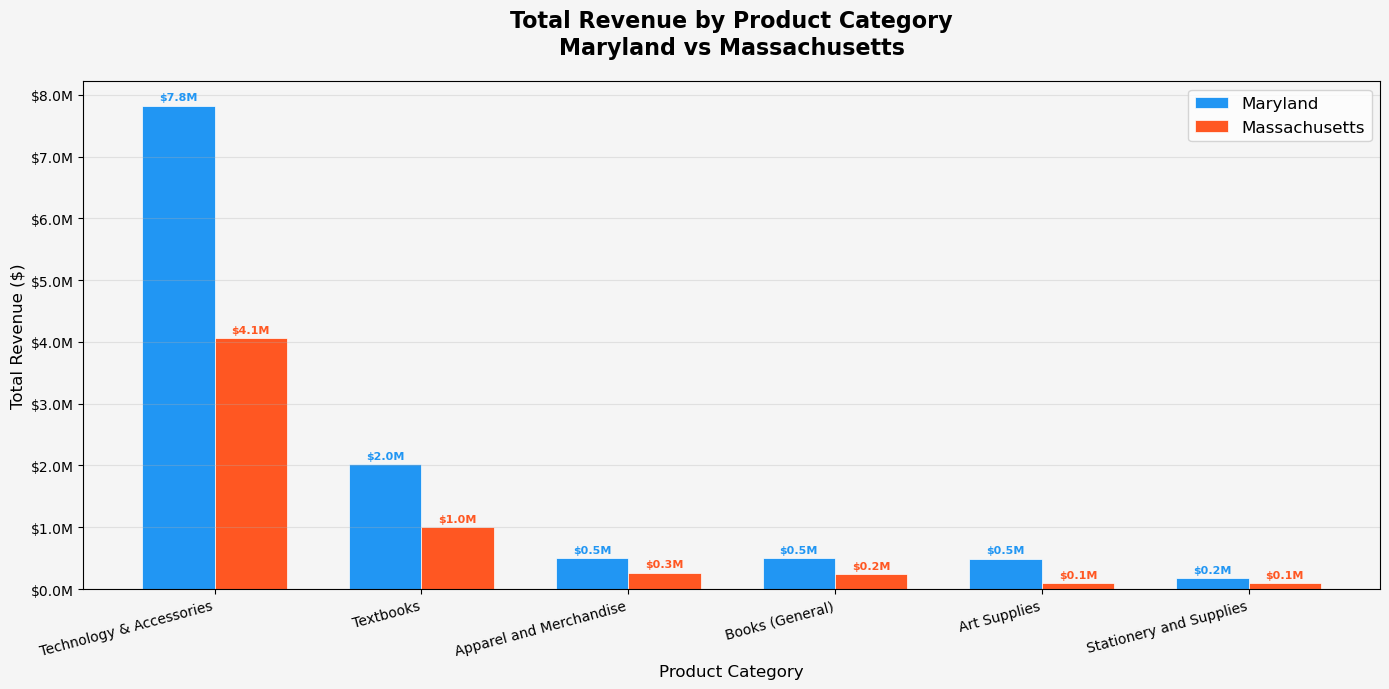

In [19]:
# Chart 2: Total Revenue by Category — Styled Bar Chart
fig, ax = plt.subplots(figsize=(14, 7))

categories_list = md_category['Category'].tolist()
md_rev = md_category['Total_Revenue'].tolist()
ma_rev = ma_category['Total_Revenue'].tolist()

x = range(len(categories_list))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], md_rev, width,
               label='Maryland', color='#2196F3', edgecolor='white', linewidth=0.5)
bars2 = ax.bar([i + width/2 for i in x], ma_rev, width,
               label='Massachusetts', color='#FF5722', edgecolor='white', linewidth=0.5)

# Add value labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'${bar.get_height()/1e6:.1f}M', ha='center', va='bottom', 
            fontsize=8, color='#2196F3', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f'${bar.get_height()/1e6:.1f}M', ha='center', va='bottom',
            fontsize=8, color='#FF5722', fontweight='bold')

ax.set_facecolor('#F5F5F5')
fig.patch.set_facecolor('#F5F5F5')
ax.set_title('Total Revenue by Product Category\nMaryland vs Massachusetts', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Total Revenue ($)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories_list, rotation=15, ha='right', fontsize=10)
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Chart 2 Insight:**
This bar chart clearly shows that Technology & Accessories is the dominant 
revenue category in both territories generating $7.8M in Maryland and $4.1M 
in Massachusetts. Textbooks is a strong second in both territories. All other 
categories generate significantly less revenue suggesting that marketing efforts 
should focus on growing these underperforming categories especially Books (General) 
in Massachusetts which has very low sales compared to Maryland.

### Chart 3: Store Performance Ranking by Territory

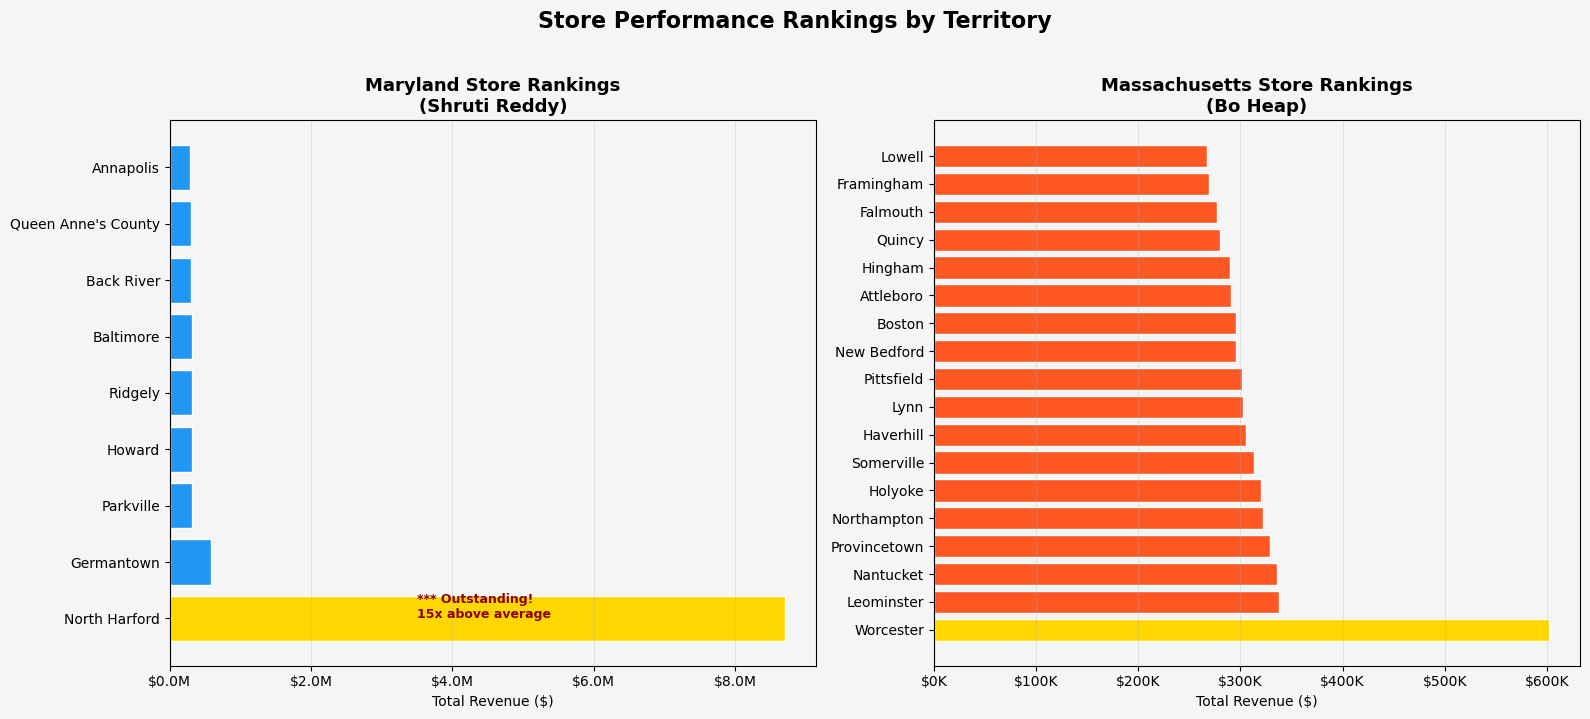

In [21]:

# Chart 3: Store Revenue Ranking — Side by Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Maryland stores
ax1.barh(md_store_revenue['Store Location'], 
         md_store_revenue['Total Revenue'],
         color=['#FFD700' if x == md_store_revenue['Total Revenue'].max() 
                else '#2196F3' for x in md_store_revenue['Total Revenue']],
         edgecolor='white')
ax1.set_title('Maryland Store Rankings\n(Shruti Reddy)', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Total Revenue ($)')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax1.grid(axis='x', alpha=0.3)
ax1.set_facecolor('#F5F5F5')

# Add annotation for North Harford
ax1.annotate('*** Outstanding!\n15x above average', 
             xy=(8708119, 'North Harford'),
             xytext=(3500000, 'North Harford'),
             fontsize=9, color='darkred', fontweight='bold')

# Massachusetts stores
ax2.barh(ma_store_revenue['Store Location'],
         ma_store_revenue['Total Revenue'],
         color=['#FFD700' if x == ma_store_revenue['Total Revenue'].max() 
                else '#FF5722' for x in ma_store_revenue['Total Revenue']],
         edgecolor='white')
ax2.set_title('Massachusetts Store Rankings\n(Bo Heap)', 
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Total Revenue ($)')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e3:.0f}K'))
ax2.grid(axis='x', alpha=0.3)
ax2.set_facecolor('#F5F5F5')

fig.patch.set_facecolor('#F5F5F5')
plt.suptitle('Store Performance Rankings by Territory', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Chart 3 Insight:**
This chart reveals a remarkable anomaly in the Maryland territory — 
North Harford (Store 736) generates $8.7M in total revenue which is 
15x higher than the second ranked Maryland store Germantown at $584K. 
This extraordinary performance warrants further investigation to understand 
what drives North Harford's success and whether those strategies can be 
replicated across other stores. In Massachusetts Worcester leads with $602K 
followed by Leominster at $338K with stores performing more consistently 
across the territory.